# **Deep Vision**

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR-100.


### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar sera de incluir la utilización de una red preentrenada con el dataset CIFAR100, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Tras esto, se aplicarán distintas técnicas de optimización para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal profunda a diseñar, entrenar y optimizar. Se aplicarán distintas técnicas de optimización para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

# **Pre processing**

## **- Conexion a Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
###################################################################################################
BASE_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Nuclio/ML/DeepLearning/Entregable-4-DeepLearning/'
###################################################################################################

## **- Obtención del dataset CIFAR100**

Dataset CIFAR 100
- Datos originales:
  - https://keras.io/api/datasets/cifar100/
  - https://www.cs.toronto.edu/~kriz/cifar.html

## **- Importación de librarías**

In [3]:
# Import the necessary packages
import os
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tarfile
import pickle
import random
%matplotlib inline

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import backend as K
from tensorflow.keras.layers import ( Input, Conv2D, Activation, Flatten, Dense,
                                     Dropout, BatchNormalization, MaxPooling2D,
                                      GlobalAveragePooling2D )
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## **- Definición de las funciones de entrenamiento**

In [19]:
def train_model(x_train_data, y_train_data, x_test_data, y_test_data, pre_trained_model, p_epochs = 15, datagen = None, display_graph = True):
  print("[INFO]: Inicio Fase entrenamiento...")
  t0 = time.time()

  callbacks = [
      EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
      ReduceLROnPlateau(factor=0.5, patience=3, verbose=1, monitor='val_loss')
  ]

  if datagen is not None:
    model_train_response = pre_trained_model.fit(
        datagen.flow(x_train_data, y_train_data, batch_size=128),
        epochs=p_epochs,
        validation_data=(x_test_data, y_test_data),
        callbacks=callbacks,
        verbose=1
    )
  else:
      model_train_response = pre_trained_model.fit(
        x_train_data, y_train_data,
        epochs=p_epochs,
        validation_data=(x_test_data, y_test_data),
        callbacks=callbacks,
        verbose=1,
        batch_size=128 # Specify batch_size when not using a generator
    )

  tiempo_res_p1 = time.time() - t0
  print(f"[INFO]: Inicio Fase entrenamiento completada en {tiempo_res_p1:.0f}s")

  if(display_graph == True):
    print(pre_trained_model.name)
    plot_historia({pre_trained_model.name: model_train_response},
                  titulo=f"Curvas de entrenamiento para {pre_trained_model.name}")

  return model_train_response
  # Get the actual number of epochs trained
  #N = len(model_train_response.history["loss"])

  # Gráficas
  #plt.style.use("ggplot")
  #plt.figure()
  #plt.plot(np.arange(0, N), model_train_response.history["loss"], label="train_loss")
  #plt.plot(np.arange(0, N), model_train_response.history["val_loss"], label="val_loss")
  #plt.plot(np.arange(0, N), model_train_response.history["accuracy"], label="train_acc")
  #plt.plot(np.arange(0, N), model_train_response.history["val_accuracy"], label="val_acc")
  #plt.title("Training Loss and Accuracy")
  #plt.xlabel("Epoch #")
  #plt.ylabel("Loss/Accuracy")
  #plt.legend()
  #plt.show()

def plot_historia(historias: dict, titulo: str = "Curvas de entrenamiento") -> None:
    """
        Grafica las curvas de entrenamiento (accuracy y loss) para uno o varios modelos

        Args:
        ----------
            historias: {nombre_modelo: History}, donde History es el objeto devuelto por .fit()
            titulo: título general del gráfico
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10.colors

    for idx, (nombre, history) in enumerate(historias.items()):
        c = colors[idx % len(colors)]
        axes[0].plot(history.history['accuracy'], color=c, linestyle='-', label=f'{nombre} Train')
        axes[0].plot(history.history['val_accuracy'], color=c, linestyle='--', label=f'{nombre} Val')
        axes[1].plot(history.history['loss'], color=c, linestyle='-', label=f'{nombre} Train')
        axes[1].plot(history.history['val_loss'], color=c, linestyle='--', label=f'{nombre} Val')

    for ax, ylabel in zip(axes, ['Accuracy', 'Loss']):
        ax.set_title(ylabel, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(titulo, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

#Evaluacion
def evaluate_model(model, x_test, y_test):
  print("[INFO]: Evaluando test...")
  loss_res, acc_res = model.evaluate(x_test, y_test, verbose=0)
  params_res = model.count_params()
  print(f"Test Accuracy: {acc_res:.4f} | Test Loss: {loss_res:.4f}")
  print(f"Parámetros totales: {params_res:,}")
  return loss_res, acc_res, params_res

# Data aumentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_data_augmentation(x_train):
  # Data augmentation solo en train
  dataAugmentation = ImageDataGenerator(
      horizontal_flip=True,
      rotation_range=15,
      width_shift_range=0.1,
      height_shift_range=0.1,
      zoom_range=0.1
  )
  dataAugmentation.fit(trainX_norm)
  return dataAugmentation

## **- Cargando el conjunto de datos**

In [5]:
(x_train, y_train), (x_valid, y_valid) = cifar100.load_data()

assert x_train.shape == (50000, 32, 32, 3)
assert x_valid.shape == (10000, 32, 32, 3)

assert y_train.shape == (50000, 1)
assert y_valid.shape == (10000, 1)

print(f"Train: {x_train.shape} | Valid: {x_valid.shape}")
print(f"Valores píxel — min: {x_train.min()}, max: {x_train.max()}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train: (50000, 32, 32, 3) | Valid: (10000, 32, 32, 3)
Valores píxel — min: 0, max: 255


## **- Inspeccionando el conjunto de datos**

In [6]:
labelNames = np.unique(y_train)
print("Las %d clases son: " %(len(labelNames)))
print(labelNames)

Las 100 clases son: 
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


In [7]:
cifar100_labels = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

(50000, 32, 32, 3)
50000
42954


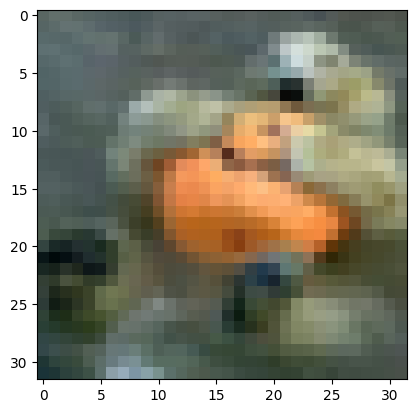

La clase es [3]
El nombre de la clase es bear


In [8]:
print(x_train.shape)
print(len(y_train))

# show image
idx = np.random.randint(0, len(x_train))
print(idx)
imgplot = plt.imshow(x_train[idx])
plt.show()
print("La clase es %s" %(y_train[idx]))
print("El nombre de la clase es %s" %(cifar100_labels[y_train[idx][0]]))


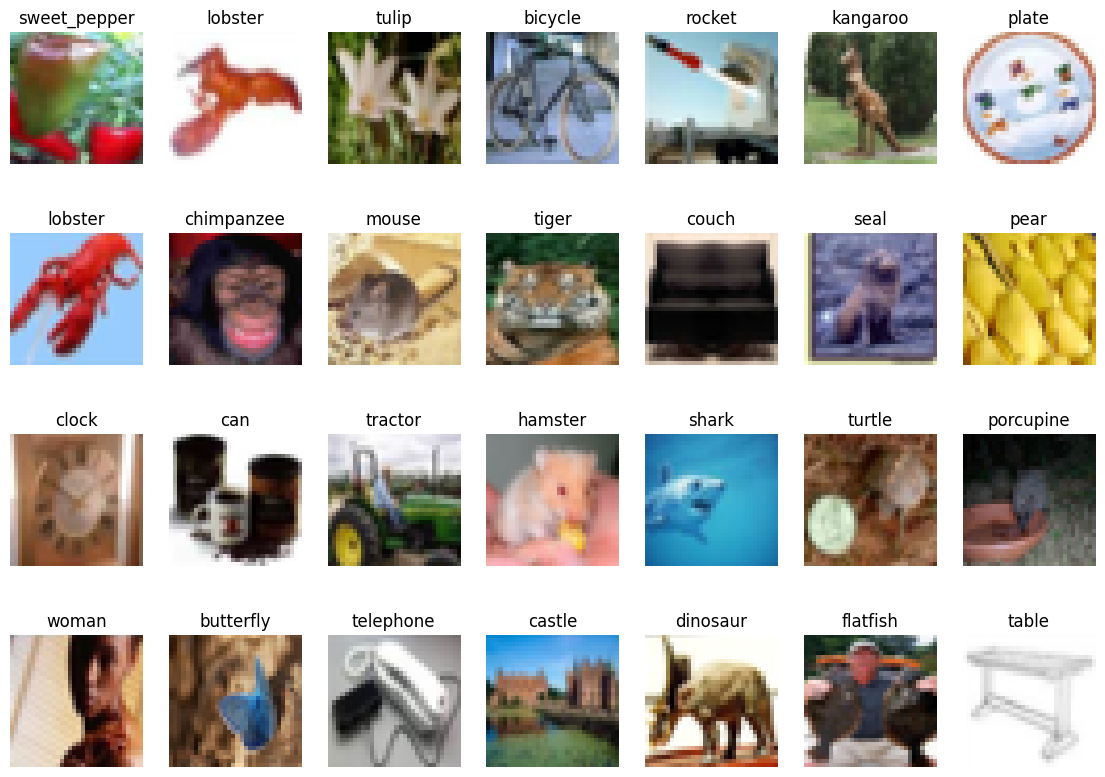

In [9]:
fig = plt.figure(figsize=(14,10))

for n, i in enumerate(random.sample(range(1,len(y_train)), 28)):
    fig.add_subplot(4, 7, n+1)
    img = x_train[i]
    plt.imshow(img)
    #plt.title(y_train[i])
    plt.title(cifar100_labels[y_train[i][0]])
    plt.axis('off')

[Text(0.5, 1.0, 'Número de muestras por clase'),
 Text(0, 0.5, 'Número de muestras')]

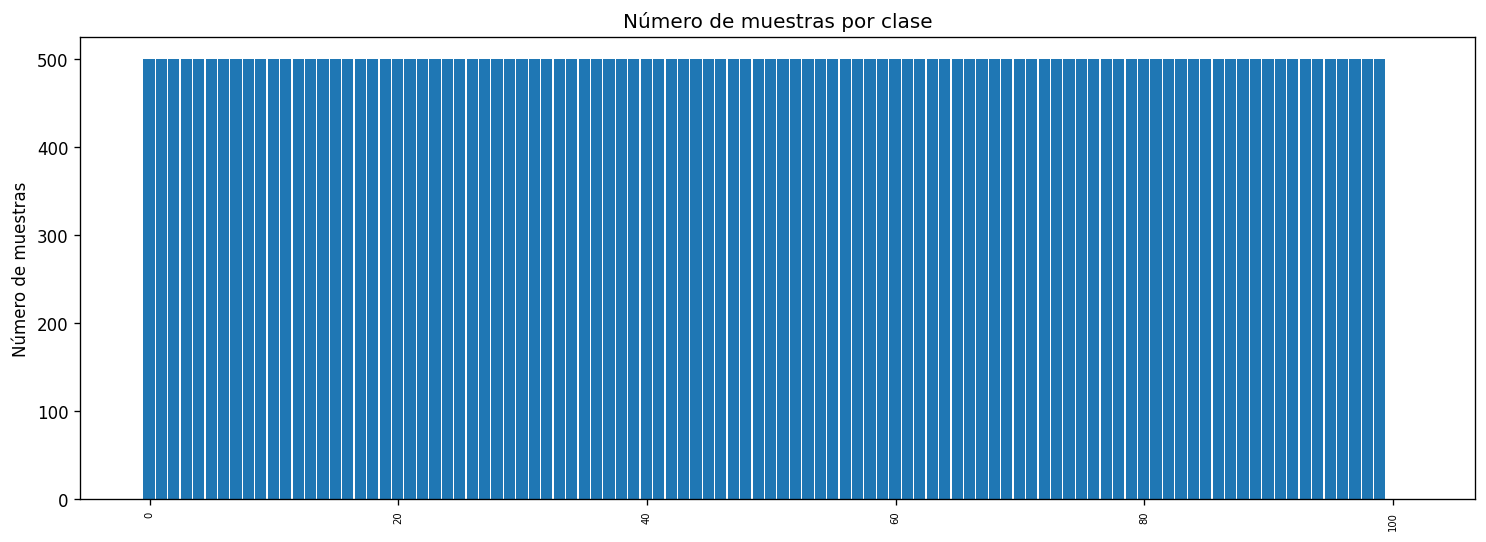

In [10]:
plt.rcParams.update({'figure.figsize':(15,5), 'figure.dpi':120})

# Plot Histogram on x
plt.hist(y_train, bins=range(0,103), width=0.9, align='left')
plt.xticks(rotation = 90, size=6)
plt.gca().set(title='Número de muestras por clase', ylabel='Número de muestras')

Se observa una clara distribución desbalanceada de las muestras.

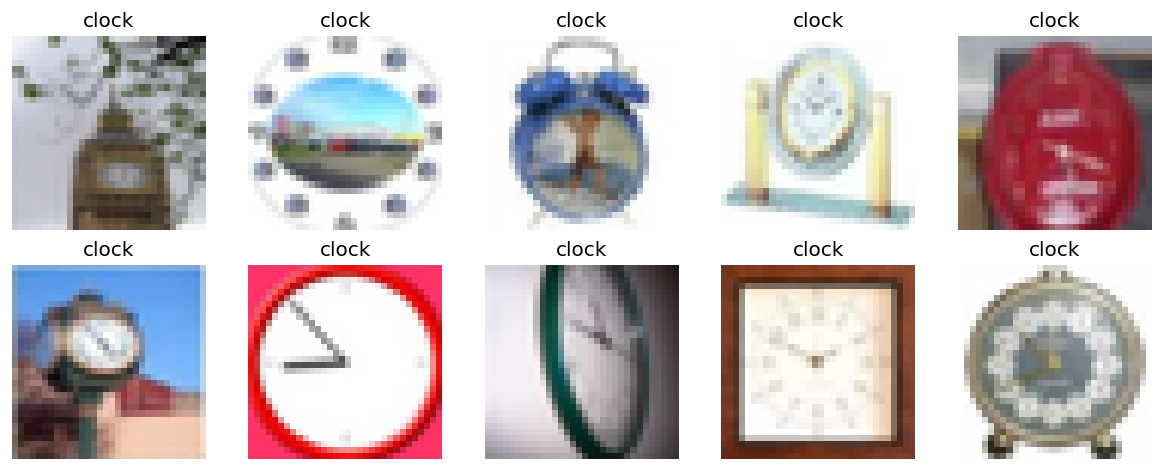

In [11]:
label_name = "clock"

# 1. Get class index
idx = cifar100_labels.index(label_name)

# 2. Get all indices of that class
indices = np.where(y_train.flatten() == idx)[0]

# 3. Select first 11 images (or fewer if needed)
selected = indices[:10]

# 4. Grid configuration
cols = 5
rows = (len(selected) + cols - 1) // cols

plt.figure(figsize=(cols * 2, rows * 2))

for i, img_idx in enumerate(selected):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_train[img_idx])
    plt.title(label_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


## **- Partition data**

In [12]:
# Validación: hold-out split 80% train - 20% test
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

## **- Transformation data**

In [13]:
# Convert class labels (integers) into a one-hot encoded format.
trainY_cat = to_categorical(y_train, 100)
testY_cat  = to_categorical(y_test,  100)

In [14]:
# Normalización simple [0,1] — válida para las tres arquitecturas elegidas
#trainX_norm = x_train.astype("float32") / 255.0
#testX_norm  = x_test.astype("float32")  / 255.0

trainX_norm = x_train.astype("float32")
testX_norm  = x_test.astype("float32")

print(f"Values after normalization — min: {trainX_norm.min():.2f}, max: {trainX_norm.max():.2f}")

Values after normalization — min: 0.00, max: 255.00


In [15]:
IMG_SIZE = 32
#x_train.shape

# **Estrategia 1: Red pre-entrenada**

#### **Loading CNN topology  (base model)**

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow import keras # Import keras explicitly

base_model = MobileNetV2(weights='imagenet',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False)

base_model.summary()

# conectarlo a nueva parte densa
base_model.trainable = False # Avoid modifying the base model.  -> TRANSFER LEARNING


/tmp/ipykernel_1141/529702389.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet',


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

#### **Transfer learning with base model freeze**

In [17]:
def get_pre_trained_model(base_model):
  pre_trained_model = Sequential(name = "MobileNetV2_TransferLarning")
  pre_trained_model.add(base_model)
  pre_trained_model.add(layers.GlobalAveragePooling2D())
  pre_trained_model.add(layers.BatchNormalization())

  pre_trained_model.add(layers.Flatten())
  pre_trained_model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
  pre_trained_model.add(layers.Dropout(0.5))
  pre_trained_model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
  pre_trained_model.add(layers.Dropout(0.3))
  pre_trained_model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
  pre_trained_model.add(layers.Dropout(0.2))
  #pre_trained_model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
  #pre_trained_model.add(layers.Dropout(0.2))

  pre_trained_model.add(layers.Dense(100, activation='softmax')) # Changed to 100 classes for CIFAR-100

  #Compile model with gradient clipping
  pre_trained_model.compile(optimizer=Adam(learning_rate=1e-3, clipvalue=1.0), # Added clipvalue for gradient clipping
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

  pre_trained_model.summary()
  return pre_trained_model

pre_trained_model = get_pre_trained_model(base_model)

Model: "MobileNetV2_TransferLarning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,096,100 (11.81 MB)

 Trainable params: 835,556 (3.19 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

##### **Training model**

In [18]:
dataAugmentation = get_data_augmentation(trainX_norm)


# Separamos validación manualmente para poder usar el generador
#val_split = int(0.9 * len(trainX_norm))
#x_train, x_test = trainX_norm[:val_split], trainX_norm[val_split:]
#y_train, y_test = trainY_cat[:val_split],  trainY_cat[val_split:]

[INFO]: Inicio Fase entrenamiento...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 251ms/step - accuracy: 0.0175 - loss: 4.6235 - val_accuracy: 0.0227 - val_loss: 4.5458 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.0258 - loss: 4.5319 - val_accuracy: 0.0349 - val_loss: 4.4734 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 245ms/step - accuracy: 0.0301 - loss: 4.5015 - val_accuracy: 0.0338 - val_loss: 4.4556 - learning_rate: 0.0010
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 270ms/step - accuracy: 0.0295 - loss: 4.4888 - val_accuracy: 0.0362 - val_loss: 4.4459 - learning_rate: 0.0010
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.0338 - loss: 4.4739 - val_accuracy: 0.0356 - val_loss: 4.4346 - learning_rate: 0.0010
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 245ms/step - accuracy: 0.0338 - loss: 4.4672 - val_accuracy: 0.0383 - val_loss: 4.4246 - learning_rate: 0.0010
Epoch 7/50
313/313 ━━━━━━━━━━━━━━

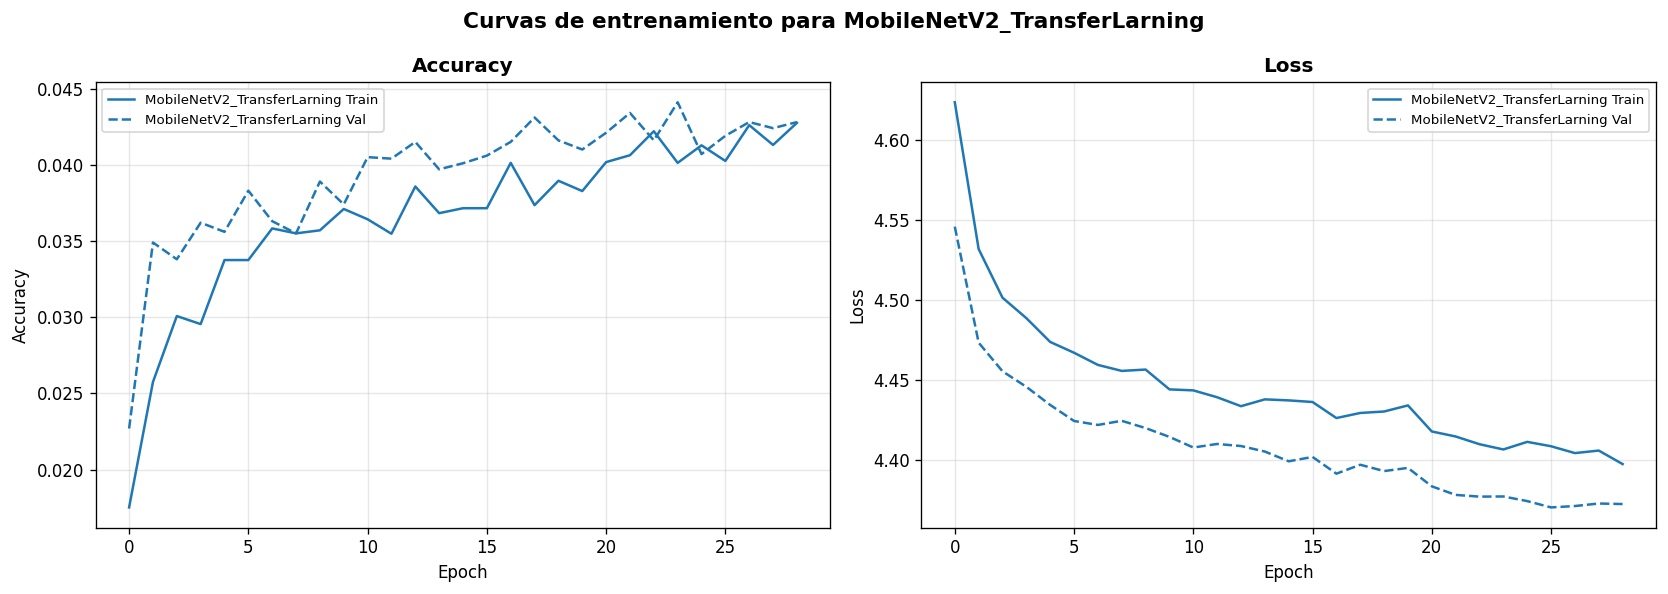

In [19]:
train_model(trainX_norm, trainY_cat, testX_norm, testY_cat, pre_trained_model, datagen=dataAugmentation, p_epochs=50)

#train_model(x_train, y_train, x_test, y_test, pre_trained_model, datagen=dataAugmentation)

##### **Evaluation**

In [20]:
evaluate_model(pre_trained_model, testX_norm, testY_cat)


[INFO]: Evaluando test...
Test Accuracy: 0.0441 | Test Loss: 4.3775
Parámetros totales: 3,096,100


(4.37746524810791, 0.04410000145435333, 3096100)

Fine tunning

In [21]:
# On gèle tout jusqu'au bloc 13 (index 116)
for layer in base_model.layers[:116]:
    layer.trainable = False

# On dégèle les blocs 13 à 16
for layer in base_model.layers[116:]:
    layer.trainable = True

base_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
pre_trained_model = get_pre_trained_model(base_model)

Model: "MobileNetV2_TransferLarning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,096,100 (11.81 MB)

 Trainable params: 2,516,900 (9.60 MB)

 Non-trainable params: 579,200 (2.21 MB)

[INFO]: Inicio Fase entrenamiento...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 165s 481ms/step - accuracy: 0.0217 - loss: 4.7019 - val_accuracy: 0.0181 - val_loss: 4.7286 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 472ms/step - accuracy: 0.0417 - loss: 4.4620 - val_accuracy: 0.0267 - val_loss: 4.6387 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 155s 497ms/step - accuracy: 0.0594 - loss: 4.3000 - val_accuracy: 0.0221 - val_loss: 4.8895 - learning_rate: 0.0010
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 472ms/step - accuracy: 0.0724 - loss: 4.2036 - val_accuracy: 0.0321 - val_loss: 4.9365 - learning_rate: 0.0010
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 156s 497ms/step - accuracy: 0.0796 - loss: 4.1411 - val_accuracy: 0.0602 - val_loss: 4.5186 - learning_rate: 0.0010
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 471ms/step - accuracy: 0.0869 - loss: 4.0794 - val_accuracy: 0.0670 - val_loss: 4.4895 - learning_rate: 0.0010
Epoch 7/50
313/313 ━━━━━━━━

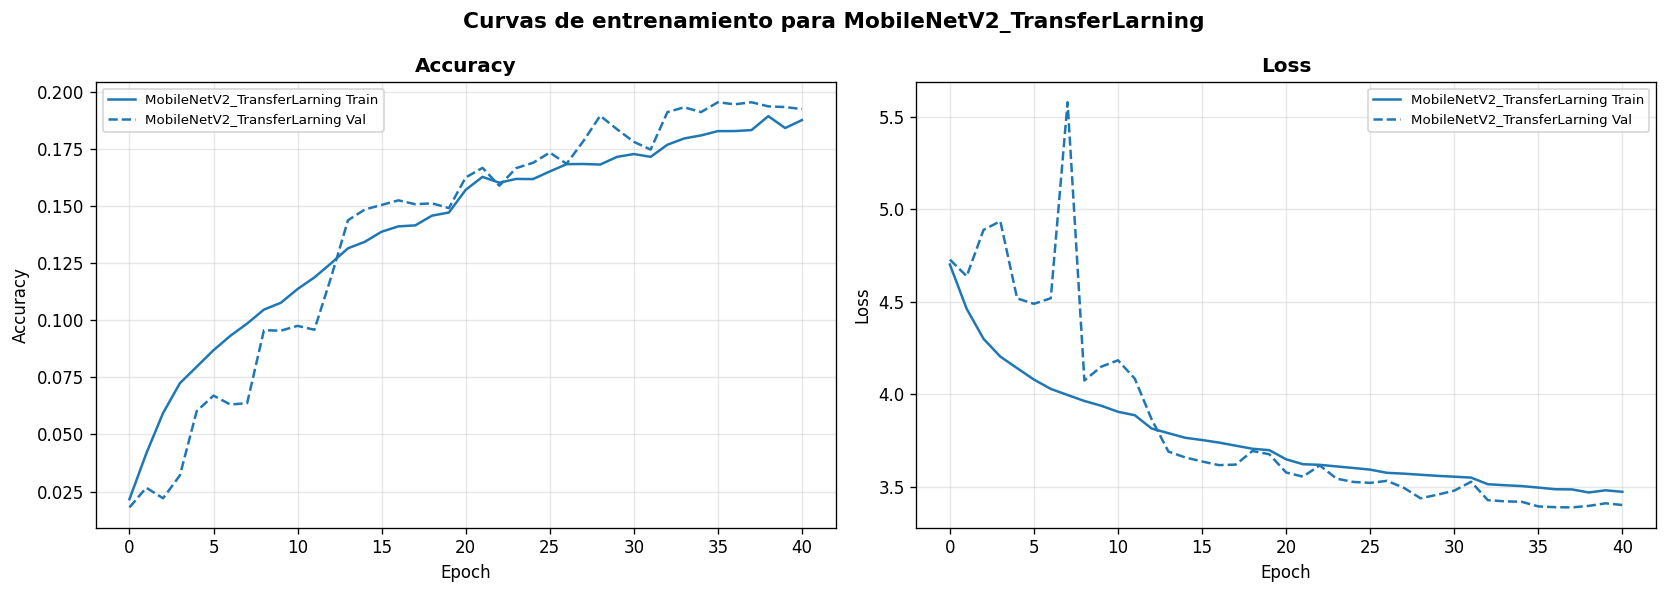

In [23]:
train_model(trainX_norm, trainY_cat, testX_norm, testY_cat, pre_trained_model, datagen=dataAugmentation, p_epochs=50)



In [24]:

acc_res, loss_res, params_res = evaluate_model(pre_trained_model, testX_norm, testY_cat)

[INFO]: Evaluando test...
Test Accuracy: 0.1953 | Test Loss: 3.3928
Parámetros totales: 3,096,100


# **Estrategia 2: Entrenar desde cero o from scratch**

#### **Definición del modelo CNN 'from scratch'**

In [23]:
def create_model_from_scratch():
    model = Sequential([
        # Bloque 1
        Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3), kernel_regularizer=regularizers.l2(1e-4)),
        Activation('relu'),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        Activation('relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Bloque 2
        Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        Activation('relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        Activation('relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Bloque 3
        Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        Activation('relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        Activation('relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Capas Denses (Clasificador)
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(100, activation='softmax') # 100 clases para CIFAR-100
    ])

    # Compilar el modelo con gradient clipping
    model.compile(optimizer=Adam(learning_rate=0.001, clipvalue=1.0), # Added clipvalue for gradient clipping
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

model_scratch = create_model_from_scratch()
model_scratch.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,391,236 (5.31 MB)

 Trainable params: 1,389,316 (5.30 MB)

 Non-trainable params: 1,920 (7.50 KB)

#### **Entrenamiento del modelo 'from scratch'**

Entrenando el modelo desde cero...
[INFO]: Inicio Fase entrenamiento...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 130ms/step - accuracy: 0.0918 - loss: 4.4630 - val_accuracy: 0.1078 - val_loss: 4.1546 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.1778 - loss: 3.7048 - val_accuracy: 0.2146 - val_loss: 3.4711 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.2283 - loss: 3.3419 - val_accuracy: 0.2912 - val_loss: 3.0243 - learning_rate: 0.0010
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.2800 - loss: 3.0652 - val_accuracy: 0.3062 - val_loss: 2.9513 - learning_rate: 0.0010
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.3131 - loss: 2.8799 - val_accuracy: 0.3747 - val_loss: 2.5880 - learning_rate: 0.0010
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.3420 - loss: 2.7348 - val_accuracy: 0.3783 - val_loss: 2.6059 - learning_rate: 0.0010
Epo

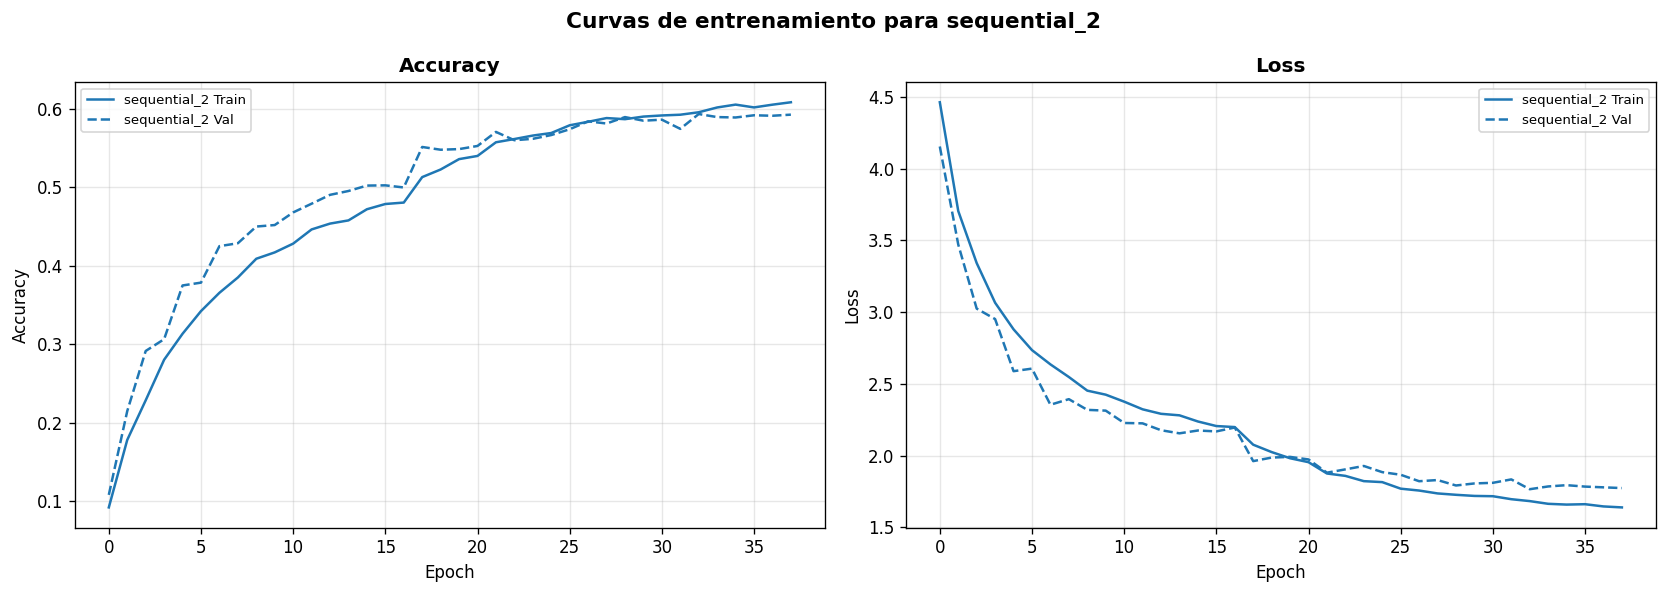

In [24]:
print("Entrenando el modelo desde cero...")

dataAugmentation = get_data_augmentation(trainX_norm)

train_model(trainX_norm, trainY_cat, testX_norm, testY_cat, model_scratch, p_epochs=50, datagen=dataAugmentation)

#### **Evaluación del modelo 'from scratch'**

In [25]:
# Evaluacion
acc_scratch, loss_scratch, params_scratch = evaluate_model(model_scratch, testX_norm, testY_cat)

[INFO]: Evaluando test...
Test Accuracy: 0.5932 | Test Loss: 1.7650
Parámetros totales: 1,391,236
